In [3]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np 
import time 
import os
import sys
import pandas as pd 

from scipy.stats import norm
import time as ttt
import iisignature as iisig
from tqdm import *
from fbm import FBM

In [4]:
from SBTS_quarticKernel import *  
from SBTS_gaussianKernel import *

# Generate Data

### GBM

In [3]:
class GBM(object):
    def __init__(self,S0,r,sigma,T, N,M):
        """
        S0: initial price
        r: Risk free rate
        sigma: vol 
        T: TTM
        N: Number of time discretization
        M: number of batches
        """
        self.S0=S0 
        self.r=r
        self.sigma=sigma
        self.T=T
        self.N=N 
        self.M=M
        
        self.Wvec=np.random.normal(size=(self.M,self.N))
        self.dt=self.T/self.N
        self.timeVec=np.linspace(0,1,self.N+1)


    def ExactSim(self): 
        Xlist=[];
        Xlist.append(np.ones(self.M)*self.S0)
        
        for i in range(self.N): 
            S0=Xlist[-1]
            S1=S0*np.exp((self.r-0.5*self.sigma**2)*self.dt+self.sigma*self.Wvec[:,i]*np.sqrt(self.dt))
            Xlist.append(S1)
            
        return np.array(Xlist).transpose()

    def EulerSim(self):
        Xlist=[];
        Xlist.append(np.ones(self.M)*self.S0)

        for i in range(self.N):
            S0=Xlist[-1]
            S1=S0+S0*self.r*self.dt + S0*self.sigma* np.sqrt(self.dt)*self.Wvec[:,i]
            Xlist.append(S1)  
        return np.array(Xlist).transpose()

In [7]:
r=0.01
sigma=1.0
T=1.0
N=100
M=1000

In [8]:
gbm=GBM(1,r=r,sigma=sigma,T=T,N=N,M=M)
Xvec=gbm.ExactSim()

In [9]:
np.mean(np.maximum((Xvec[:,-1]-0.85),0))*np.exp(-r*T)

0.45566544253707125

In [10]:
Xvec=torch.tensor(Xvec).unsqueeze(dim=2)

In [11]:
Xvec[:,0,:].mean()

tensor(1., dtype=torch.float64)

# Testing

In [12]:
h=0.05; T=1.0; Ntime=101; Nstep=100 ## Ntime=61 since we start from 0. 

In [13]:
model_og=timeSB_OG_Quartic(Xvec,h=h,time=T,Ntime=Ntime,Nstep=Nstep)
model_sig=timeSB_Sig_Quartic(Xvec,h=h,time=T,Ntime=Ntime,Nstep=Nstep)

In [14]:
sampled_list_og=[]
j=0;
time0=time.time()
while j <=M: 
    temp_vec=model_og.mainsweep()
    if not torch.isnan(temp_vec).any():
        sampled_list_og.append(temp_vec)
        j+=1
time1=time.time()
time1-time0

1206.5228381156921

In [15]:
sampled_res=torch.stack(sampled_list_og)
#torch.mean(0.5*(1-torch.log(torch.sum((sampled_res[:,:-1]-sampled_res[:,1:])**2,axis=1))/np.log(N)))

In [16]:
sampled_list_sig=[]
j=0; 
time0=time.time()
while j <M: 
    temp_vec=model_sig.mainsweep()
    if not torch.isnan(temp_vec).any():
        sampled_list_sig.append(temp_vec)
        j+=1
time1=time.time()
time1-time0

1521.8591470718384

In [17]:
sampled_res_sig=torch.stack(sampled_list_sig)
#torch.mean(0.5*(1-torch.log(torch.sum((sampled_res_sig[:,:-1]-sampled_res_sig[:,1:])**2,axis=1))/np.log(N)))

In [18]:
model_vp=timeSB_VP_Quartic(Xvec,h=0.04,tau=2.0,time=1.0,Ntime=Ntime,Nstep=Nstep)

In [19]:
sampled_list_vp=[]
j=0; 
time0=time.time()
while j <=M: 
    temp_vec=model_vp.mainsweep()
    if not torch.isnan(temp_vec).any():
        sampled_list_vp.append(temp_vec)
        j+=1
time1=time.time()
time1-time0

355.1744351387024

In [20]:
sampled_res_vp=torch.stack(sampled_list_vp)
#torch.mean(0.5*(1-torch.log(torch.sum((sampled_res_vp[:,:-1]-sampled_res_vp[:,1:])**2,axis=1))/np.log(N)))

In [21]:
df_og=pd.DataFrame(sampled_res) 
df_og['type']='og'
df_sig=pd.DataFrame(sampled_res_sig)
df_sig['type']='sig'
df_vp=pd.DataFrame(sampled_res_vp) 
df_vp['type']='vp'
df_true=pd.DataFrame(np.array(Xvec.squeeze(dim=2)))
df_true['type']='true'

In [40]:
df_data=pd.concat([df_og,df_sig,df_vp,df_true],axis=0).reset_index(drop=True)

In [41]:
#df_data.to_csv('Analysis_data/PPDE_simData/GBM_quarticPPDE10.csv')

In [24]:
def DataConstruct2(Xvec,sampled_list1,ploc1,ploc2):
    Xvec_s=Xvec.squeeze(dim=2)
    out_sample=torch.stack(sampled_list1)
    
    df_Xdata=pd.DataFrame(Xvec_s) 
    df_Xdata['type']='True Data'
    #df_Xdata.columns=['X0','X1','X2','X3','type']
    df_Xdata=df_Xdata.iloc[:,[ploc1,ploc2,-1]]
    df_Xdata.columns=['X'+str(ploc1),'X_'+str(ploc2),'type']

    df_Sigdata=pd.DataFrame(out_sample) 
    df_Sigdata['type']='Simulated Data'
    df_Sigdata=df_Sigdata.iloc[:,[ploc1,ploc2,-1]]
    df_Sigdata.columns=['X'+str(ploc1),'X_'+str(ploc2),'type']

    df_sbts=pd.concat([df_Xdata,df_Sigdata])
    return df_sbts
    

In [25]:
ploc1=6
ploc2=60

In [26]:
df_sbts_sig=DataConstruct2(Xvec,sampled_list_sig,ploc1,ploc2)

Text(0.5, 1.0, 'Sig plots')

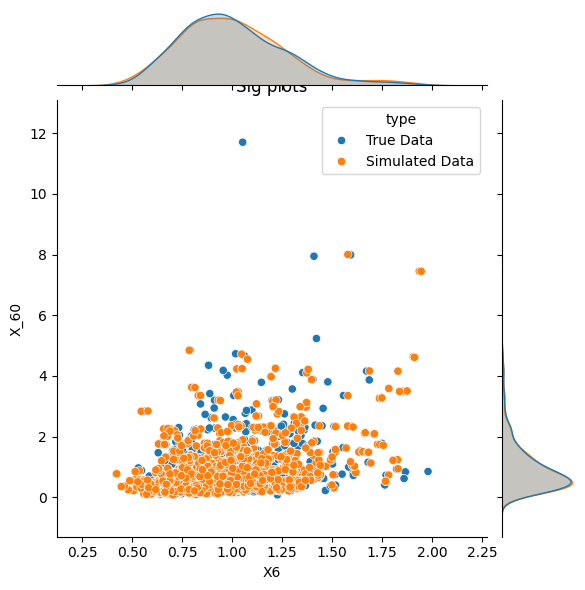

In [27]:
sns.jointplot(data=df_sbts_sig, x='X'+str(ploc1), y='X_'+str(ploc2), hue='type')
plt.title('Sig plots')

In [28]:
df_sbts_og=DataConstruct2(Xvec,sampled_list_og,ploc1,ploc2)

Text(0.5, 1.0, 'OG plots')

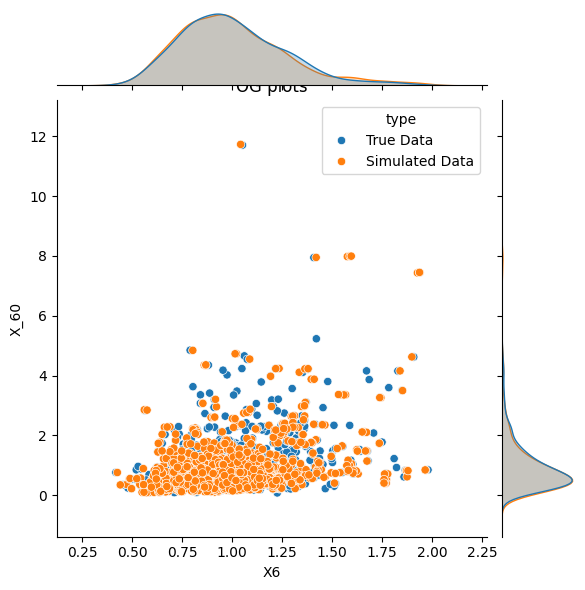

In [29]:
sns.jointplot(data=df_sbts_og, x='X'+str(ploc1), y='X_'+str(ploc2), hue='type')
plt.title('OG plots')

In [30]:
df_sbts_vp=DataConstruct2(Xvec,sampled_list_vp,ploc1,ploc2)

Text(0.5, 1.0, 'VP plots')

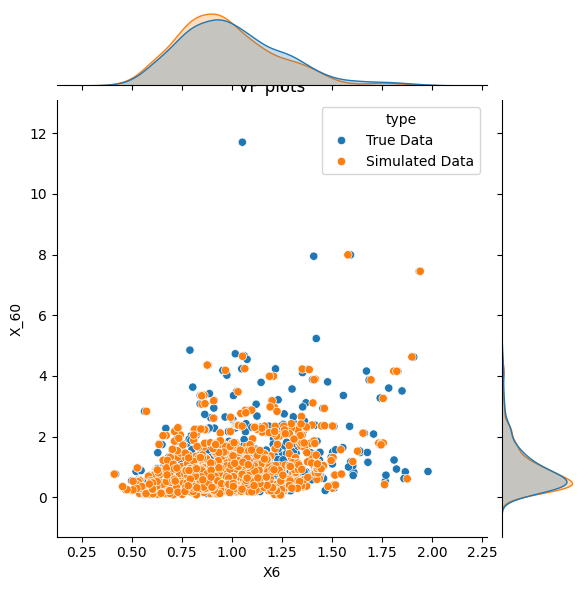

In [31]:
sns.jointplot(data=df_sbts_vp, x='X'+str(ploc1), y='X_'+str(ploc2), hue='type')
plt.title('VP plots')

In [32]:
out_sample_og=torch.stack(sampled_list_og)
out_sample_vp=torch.stack(sampled_list_vp)
out_sample_sig=torch.stack(sampled_list_sig)
Xvec_s=Xvec.squeeze(dim=2)

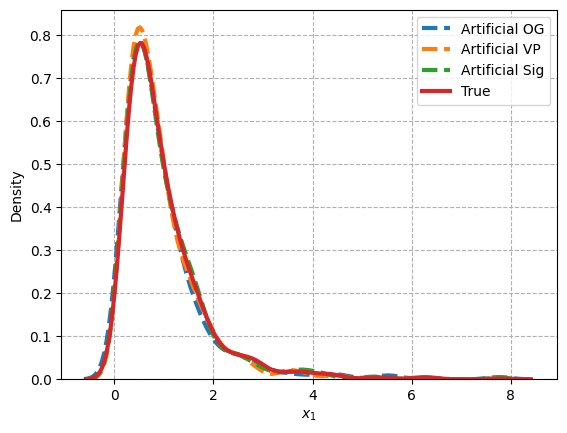

In [42]:
loc=55
sns.kdeplot(out_sample_og[:,loc],linestyle='--',linewidth=3)
sns.kdeplot(out_sample_vp[:,loc],linestyle='--',linewidth=3)
sns.kdeplot(out_sample_sig[:,loc],linestyle='--',linewidth=3)
sns.kdeplot(Xvec_s[:,loc],linewidth=3)
plt.legend(['Artificial OG','Artificial VP','Artificial Sig','True '])
plt.xlabel(r'$x_{1}$')
plt.grid(linestyle='--')

## The BS Price

In [34]:
def BS_price(df_in,r,K=0.85): 
    loc_vec=df_in.iloc[:,:-1].values[:,-1]
    price=np.mean(np.maximum((loc_vec-0.85),0))*np.exp(-r*T)
    return price

## The exact BS Price
def BS_ExactPrice(S0,K,r,T,sigma): 
    d1= (np.log(S0/K) + (r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2= (np.log(S0/K) + (r-0.5*sigma**2)*T)/(sigma*np.sqrt(T))

    price=S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    return price

def LookBack_price(df):
    arr=df.iloc[:,:-1].values
    res=np.mean(arr[:,-1]-arr.min(axis=1))
    return res

In [35]:
BS_price(df_true,r,K=0.85), BS_price(df_og,r,K=0.85),BS_price(df_sig,r,K=0.85),BS_price(df_vp,r,K=0.85)

(0.45566544253707125,
 0.408104255509131,
 0.42790556664499635,
 0.36118559538301803)

In [36]:
BS_ExactPrice(1.0,0.85,r,T,sigma)

0.43661237825605387

In [37]:
arr_t=df_true.iloc[:,:-1].values
arr_og=df_og

In [39]:
### Exact 0.5828
LookBack_price(df_true),LookBack_price(df_og),LookBack_price(df_sig),LookBack_price(df_vp)

(0.5841354084592072,
 0.5503833213501198,
 0.5433641348096894,
 0.5025648535189544)